In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

Para el TFG no se necesita ver como cambia en el eje Y de las rodillas, sino como en la pierna se dobla en grados, y para ello hay que tener en cuenta los tobillos, rodilla y cadera. 

Al ser en graddos y no en distancias sobre un eje, no hay q normalizar.

In [12]:
CSV_FOLDER = Path(r"C:\Users\david\Desktop\Results\datos_csv") 

csv_files = sorted(list(CSV_FOLDER.glob('*.csv')))[:8]

In [3]:
def calculate_angle(a, b, c):
    
    # We transform the lists to numpy arrays
    a = np.array(a) # Coordinates of the hip [x, y]
    b = np.array(b) # Coordinates of the knee [x,y]
    c = np.array(c) # Coordinates of the anke [x, y]
    
    ba = a - b
    bc = c - b
    
    # We calculate the dot product
    dot_product = np.dot(ba, bc)
    
    # We calculate the magnitudes
    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)
    
    # We calculate the cosine
    cosine_angle = dot_product / (norm_ba * norm_bc)
    
    # We force it to some values
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    
    # We calculate the arccos
    angle_radians = np.arccos(cosine_angle)

    # We convert it to degrees
    angle_degrees = np.degrees(angle_radians)

    return angle_degrees

VISUALIZAMOS EL MOVIMIENTO EN GRADOS DE LA RODILLA DERECHA.

La máxima flexión es el menor ángulo, y la mínima flexión sería lo más próximo a 180º

Procesando (1/8): flat_pinpoint_103_landmarks.csv...
Procesando (2/8): flat_pinpoint_107_landmarks.csv...
Procesando (3/8): flat_pinpoint_113_landmarks.csv...
Procesando (4/8): flat_pinpoint_115_landmarks.csv...
Procesando (5/8): flat_pinpoint_116_landmarks.csv...
Procesando (6/8): flat_pinpoint_126_landmarks.csv...
Procesando (7/8): flat_pinpoint_127_landmarks.csv...
Procesando (8/8): flat_pinpoint_132_landmarks.csv...


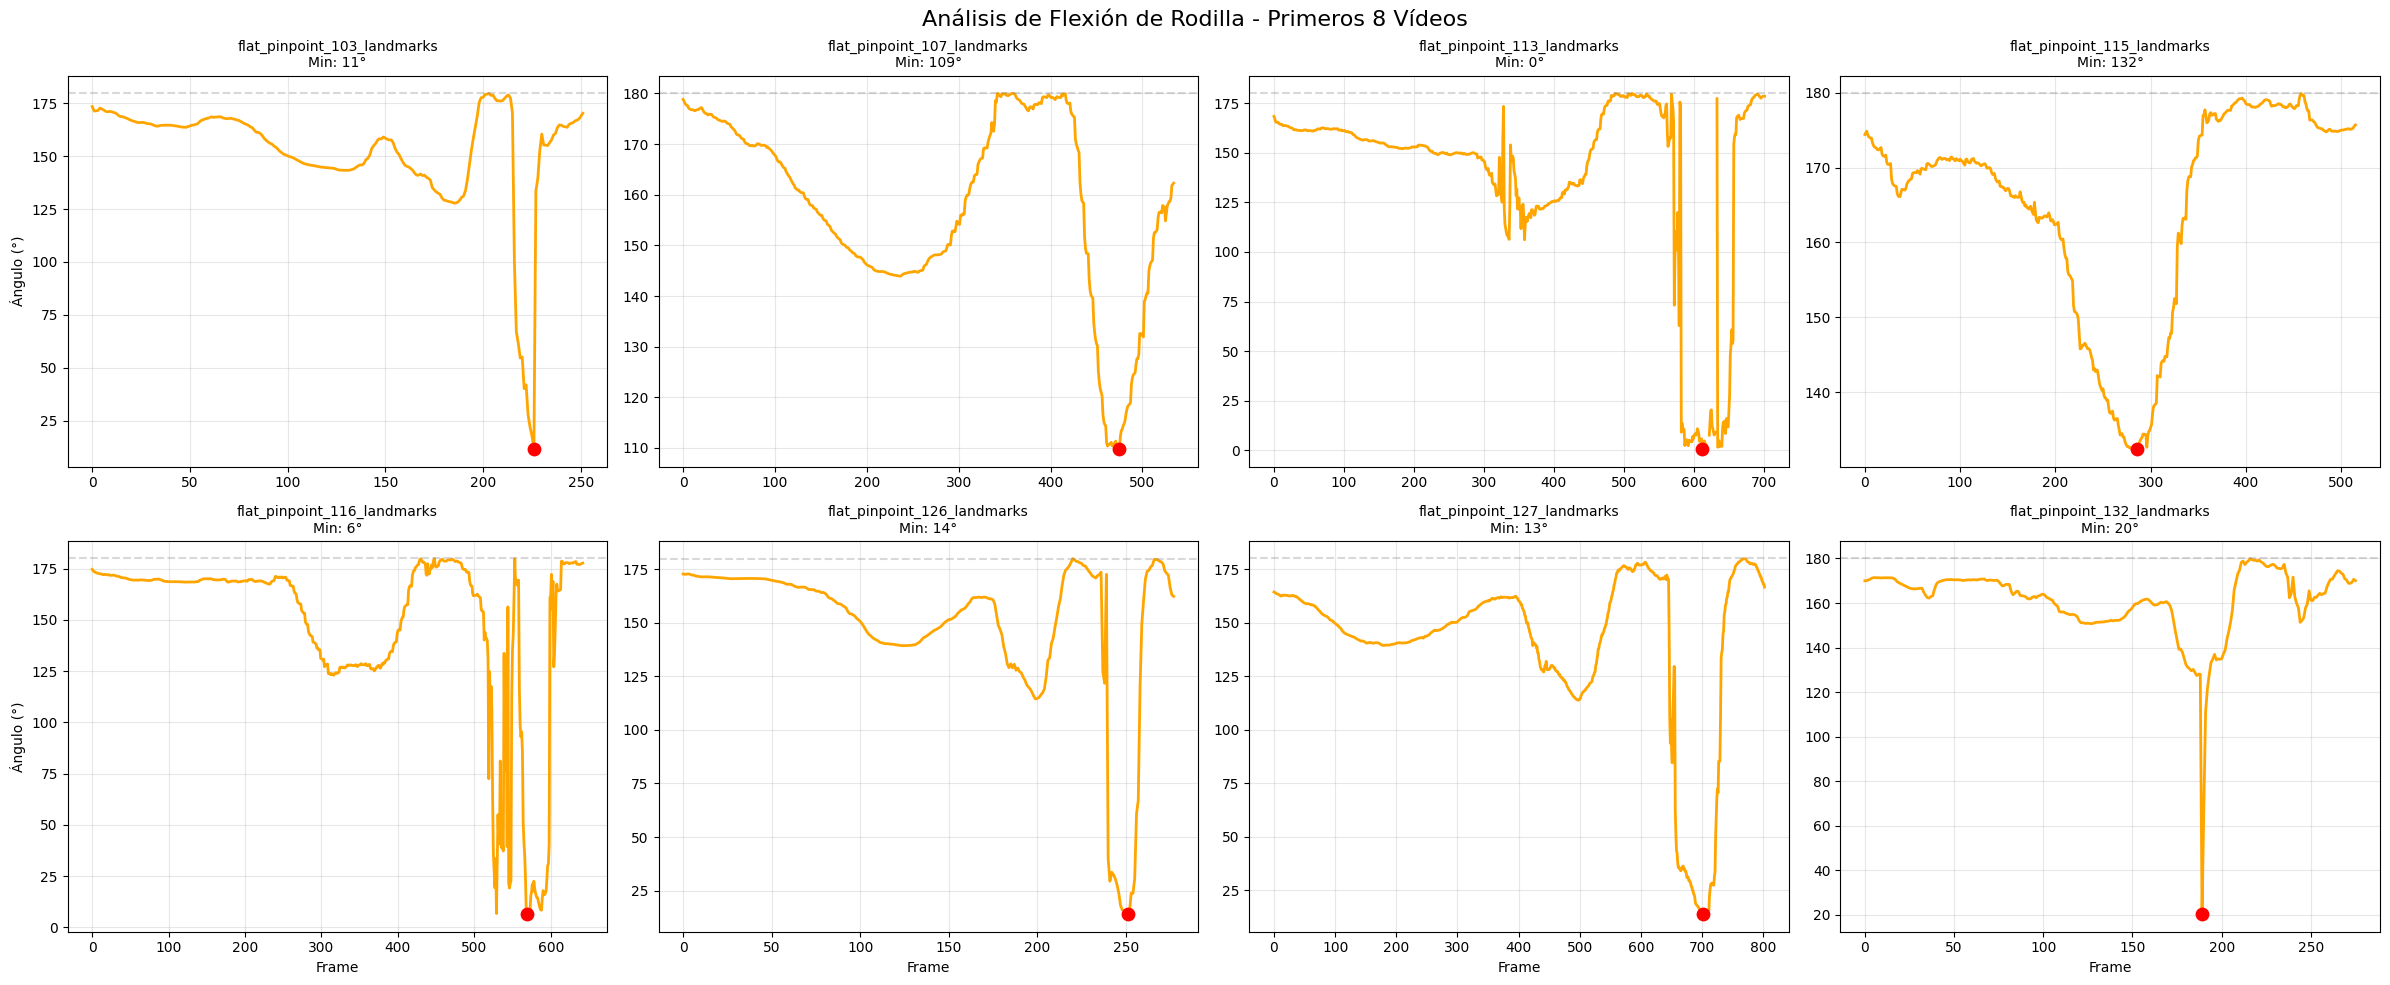

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente (0 a 7)

for idx, file_path in enumerate(csv_files):
    print(f"Procesando ({idx+1}/8): {file_path.name}")
    
    try:
        df = pd.read_csv(file_path)
        
        angulos_rodilla = [] # Lo metemos en una lista cada frame para meterlo en el dataframe.
        for i in range(len(df)):
            cadera = [df.loc[i, 'RIGHT_HIP_x'], df.loc[i, 'RIGHT_HIP_y']]
            rodilla = [df.loc[i, 'RIGHT_KNEE_x'], df.loc[i, 'RIGHT_KNEE_y']]
            tobillo = [df.loc[i, 'RIGHT_ANKLE_x'], df.loc[i, 'RIGHT_ANKLE_y']]
            
            angulo = calculate_angle(cadera, rodilla, tobillo)
            angulos_rodilla.append(angulo)
        
        df['angulo_rodilla'] = angulos_rodilla
        
        
        # ESTADÍSTICAS
        min_flexion_val = df['angulo_rodilla'].min()
        min_flexion_frame = df['angulo_rodilla'].idxmin()
        
        
        #PINTAR EN SU SUB-GRÁFICA CORRESPONDIENTE
        ax = axes[idx] # Seleccionamos el recuadro actual
        
        # Línea del ángulo
        ax.plot(df['frame_id'], df['angulo_rodilla'], color='orange', linewidth=2)
        
        # Punto de máxima flexión
        ax.scatter(df.loc[min_flexion_frame, 'frame_id'], min_flexion_val, color='red', s=80, zorder=5)
        
        # Decoración
        ax.set_title(f"{file_path.stem}\nMin: {int(min_flexion_val)}°", fontsize=10)
        ax.axhline(y=180, color='gray', linestyle='--', alpha=0.3) # Referencia recta
        ax.grid(True, alpha=0.3)
        
        # Solo ponemos etiquetas en los bordes para no ensuciar
        if idx % 4 == 0:
            ax.set_ylabel("Ángulo (°)")
        if idx >= 4:
            ax.set_xlabel("Frame")
            
    except Exception as e:
        print(f"⚠️ Error con {file_path.name}: {e}")


plt.suptitle("Análisis de Flexión de Rodilla - Primeros 8 Vídeos", fontsize=16)
plt.tight_layout()
plt.show()

Se pueden observar dos caidas notorias, la segunda caida se debe a la patada de compensación, al ser la pierna derecha, esta se queda en el aire para no perder el equilibrio, y se dobla lo que provoca esa segunda caida de flexión.

COMPARACION RIGHT_KNEE Y LEFT_KNEE

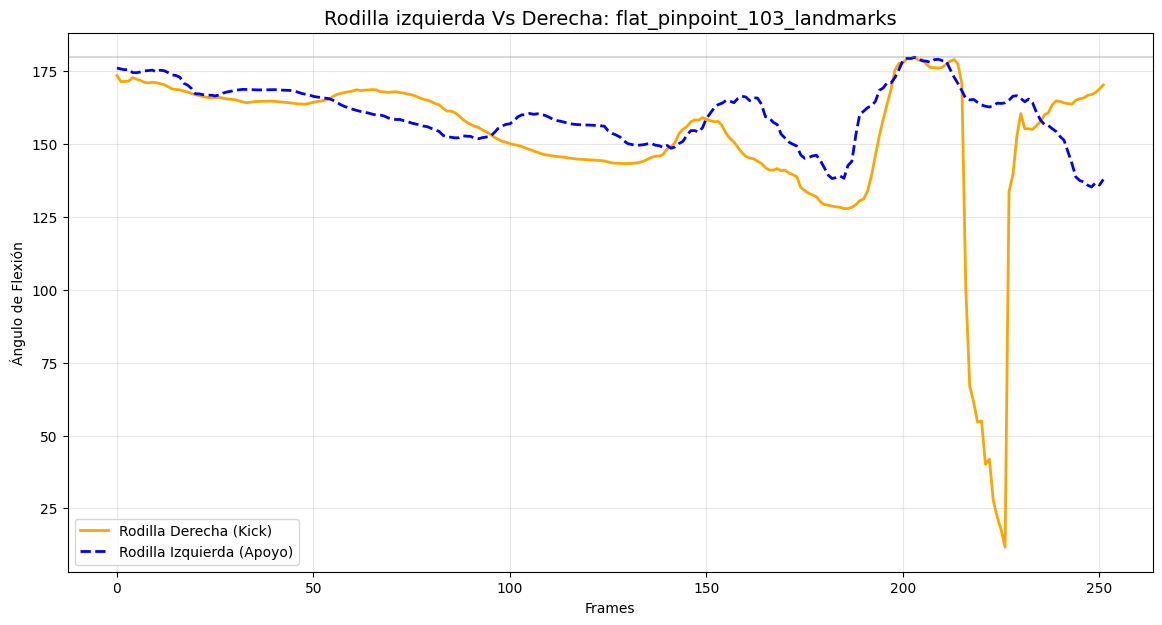

In [13]:
file_path = csv_files[0] 
df = pd.read_csv(file_path)

angulos_derecha = []
angulos_izquierda = []

for i in range(len(df)):
    r_hip = [df.loc[i, 'RIGHT_HIP_x'], df.loc[i, 'RIGHT_HIP_y']]
    r_knee = [df.loc[i, 'RIGHT_KNEE_x'], df.loc[i, 'RIGHT_KNEE_y']]
    r_ankle = [df.loc[i, 'RIGHT_ANKLE_x'], df.loc[i, 'RIGHT_ANKLE_y']]
    angulos_derecha.append(calculate_angle(r_hip, r_knee, r_ankle))
    
    l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
    l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
    l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
    angulos_izquierda.append(calculate_angle(l_hip, l_knee, l_ankle))


# VISUALIZACIÓN COMPARATIVA 
plt.figure(figsize=(14, 7))

# Gráfica Derecha (Naranja)
plt.plot(df['frame_id'], angulos_derecha, color='orange', label='Rodilla Derecha (Kick)', linewidth=2)

# Gráfica Izquierda (Azul)
plt.plot(df['frame_id'], angulos_izquierda, color='blue', label='Rodilla Izquierda (Apoyo)', linewidth=2, linestyle='--')

# Decoración
plt.title(f"Rodilla izquierda Vs Derecha: {file_path.stem}", fontsize=14)
plt.xlabel("Frames")
plt.ylabel("Ángulo de Flexión")
plt.axhline(y=180, color='gray', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Analizamos todo con el RIGHT_KNEE

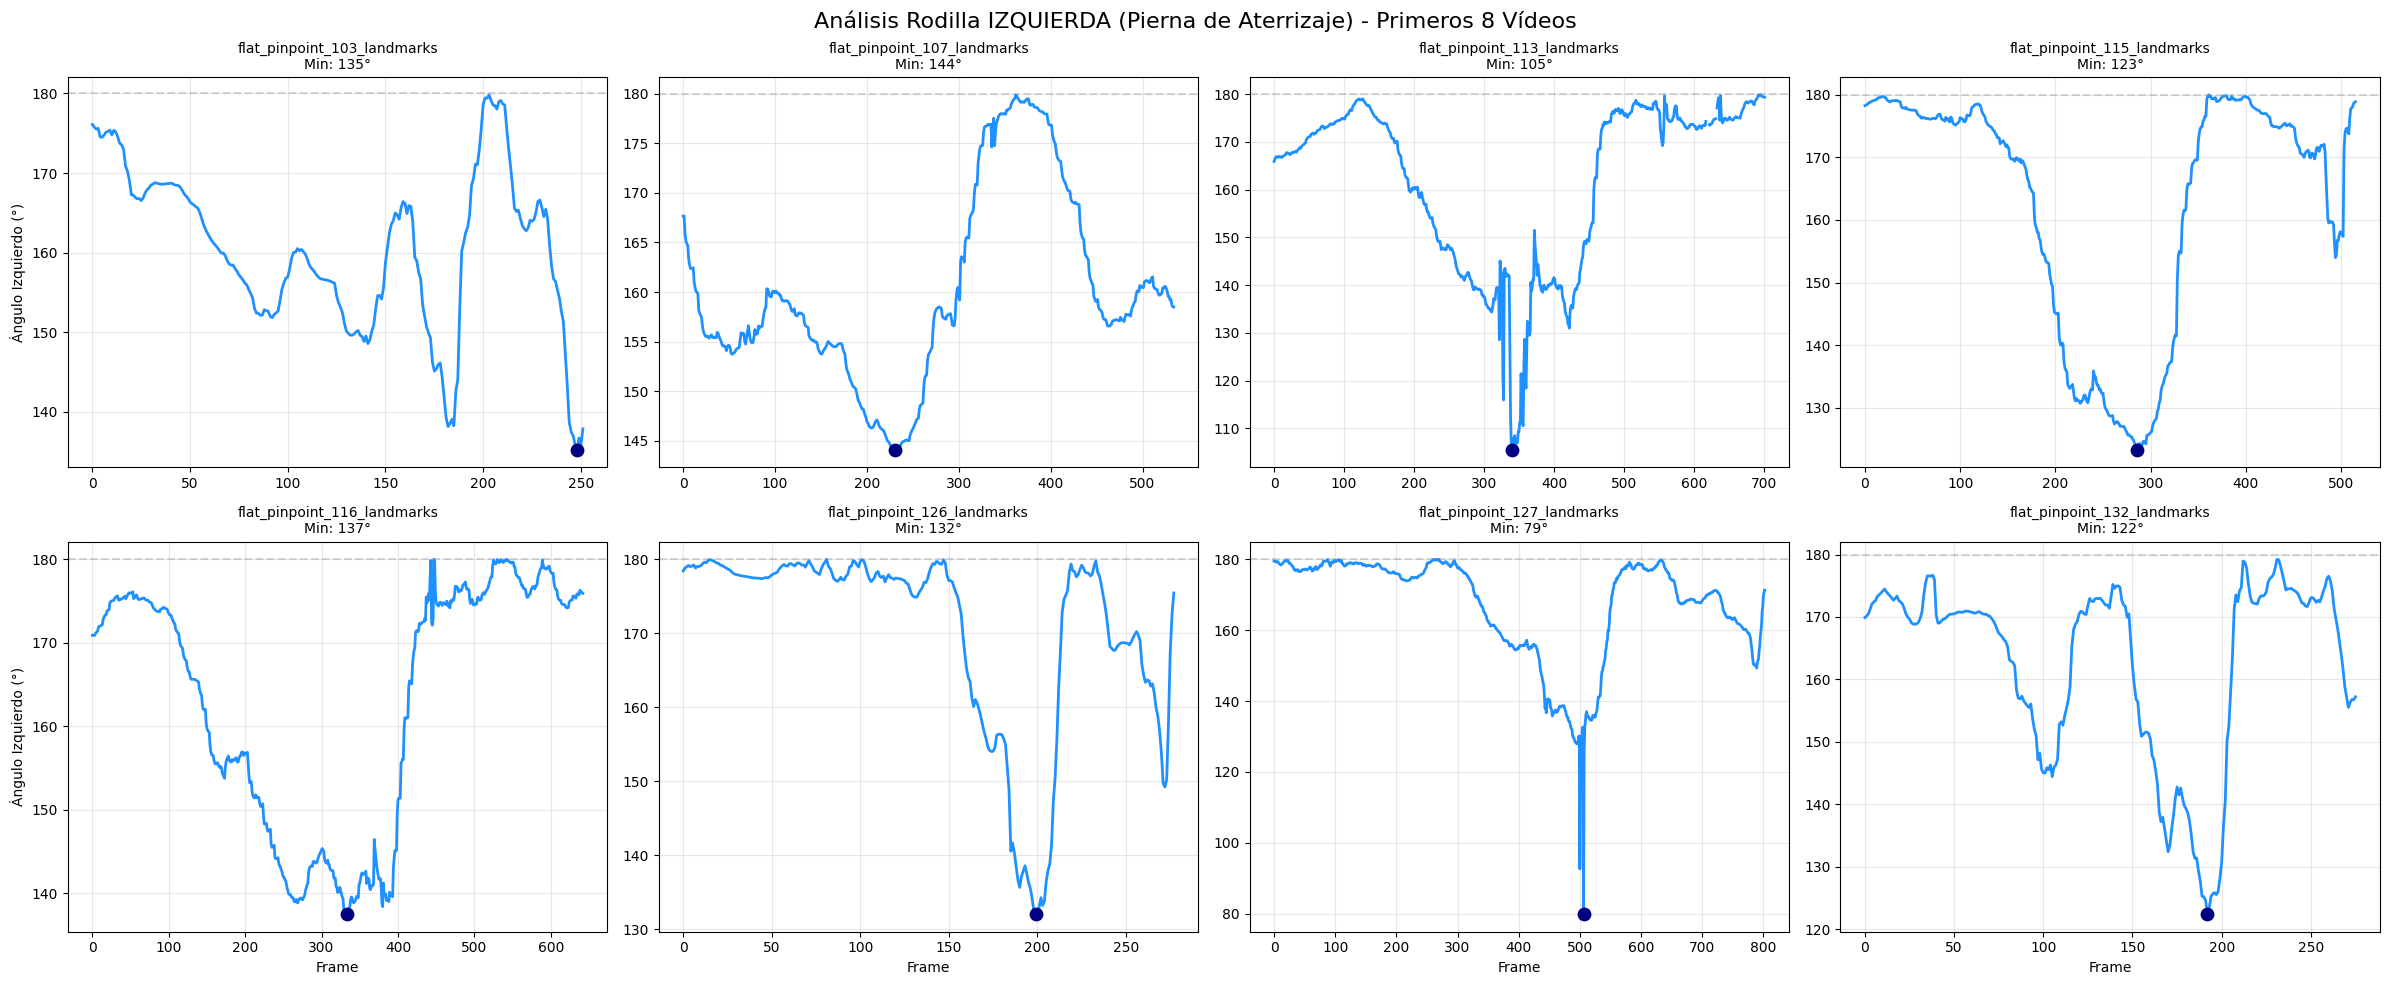

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() 

for idx, file_path in enumerate(csv_files):
    try:
        df = pd.read_csv(file_path)
        
        angulos_izquierda = []
        for i in range(len(df)):
            cadera = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            rodilla = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            tobillo = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            
            angulo = calculate_angle(cadera, rodilla, tobillo)
            angulos_izquierda.append(angulo)
        
        df['angulo_rodilla_izq'] = angulos_izquierda
        
        
        # ESTADÍSTICAS 
        min_val = df['angulo_rodilla_izq'].min()
        min_frame = df['angulo_rodilla_izq'].idxmin()
        
        # --- PINTAR ---
        ax = axes[idx] 
        ax.plot(df['frame_id'], df['angulo_rodilla_izq'], color='dodgerblue', linewidth=2)
        
        # Punto de máxima flexión
        ax.scatter(df.loc[min_frame, 'frame_id'], min_val, color='navy', s=80, zorder=5)
        
        ax.set_title(f"{file_path.stem}\nMin: {int(min_val)}°", fontsize=10)
        ax.axhline(y=180, color='gray', linestyle='--', alpha=0.3)
        ax.grid(True, alpha=0.3)
        
        if idx % 4 == 0:
            ax.set_ylabel("Ángulo Izquierdo (°)")
        if idx >= 4:
            ax.set_xlabel("Frame")
            
    except Exception as e:
        print(f"⚠️ Error en {file_path.name}: {e}")

plt.suptitle("Análisis Rodilla IZQUIERDA (Pierna de Aterrizaje) - Primeros 8 Vídeos", fontsize=16)
plt.tight_layout()
plt.show()

CONCLUSIÓN: Despues de la gran subida, no vuelve a haber otra subida tan fuerte, por lo que es más facil identificar el área que buscamos. El pico máximo en la rodilla derecha, será el ángulo 180º en el que ya estará saltando. 

Pero no vale cualquier pico 180º, tiene que ser el que venga después de la gran subida, ya que el jugador puede empezar ergido, y entonces el algoritmo no sabría cual elegir.

PASO 1: HALLAR EL PUNTO MÁXIMO: Tenemos que buscar el punto máximo que venga después del punto más mínimo. Compararlos y entonces tendremos el punto deseado. Para algo necesario es hallar la función de ordenación algoritmica necesaria:

In [ ]:
def detectar_fases_saque(angulos, max_dist_frames):
    """
    Analiza una secuencia de ángulos de rodilla y devuelve los frames clave
    basándose en la lógica de 'Mayor Rango de Movimiento Ascendente'.
    
    Returns:
        frame_carga (min), frame_extension (max), frame_target (0.325)
    """
    data = np.array(angulos)
    
    # --- PASO 1: LISTAR CANDIDATOS ---
    # Picos (Máximos) > 150º
    picos_idx, _ = find_peaks(data, height=150, distance=20)
    
    # Valles (Mínimos) < 165º (Invertimos señal)
    valles_idx, _ = find_peaks(-data, height=-165, distance=20)
    
    # --- PASO 2: BUSCAR LA MEJOR PAREJA (Mayor Subida) ---
    best_score = -1
    best_min_frame = -1
    best_max_frame = -1
    
    for valle in valles_idx:
        for pico in picos_idx:
            # Regla 1: Secuencialidad (Carga -> Extensión)
            if valle < pico:
                distancia = pico - valle
                
                # Regla 2: Coherencia temporal (apto para slow motion)
                if distancia < max_dist_frames:
                    recorrido = data[pico] - data[valle]
                    
                    # Nos quedamos con la subida más explosiva/grande
                    if recorrido > best_score:
                        best_score = recorrido
                        best_min_frame = valle
                        best_max_frame = pico
    
    # Fallback de emergencia (si no encuentra picos claros)
    if best_min_frame == -1:
        best_min_frame = np.argmin(data)
        best_max_frame = np.argmax(data)
        
    # --- PASO 3: REFINAMIENTO DEL MÍNIMO ---
    # Buscamos el píxel exacto más bajo alrededor del valle detectado
    ventana = 10
    inicio = max(0, best_min_frame - ventana)
    fin = min(len(data), best_min_frame + ventana)
    
    # argmin devuelve índice relativo, sumamos 'inicio' para absoluto
    ajuste_idx = np.argmin(data[inicio:fin])
    best_min_frame = inicio + ajuste_idx
    
    # --- PASO 4: CALCULAR TARGET (FACTOR 0.325) ---
    distancia_total = best_max_frame - best_min_frame
    target_frame = int(best_min_frame + (distancia_total * 0.325))
    
    return best_min_frame, best_max_frame, target_frame

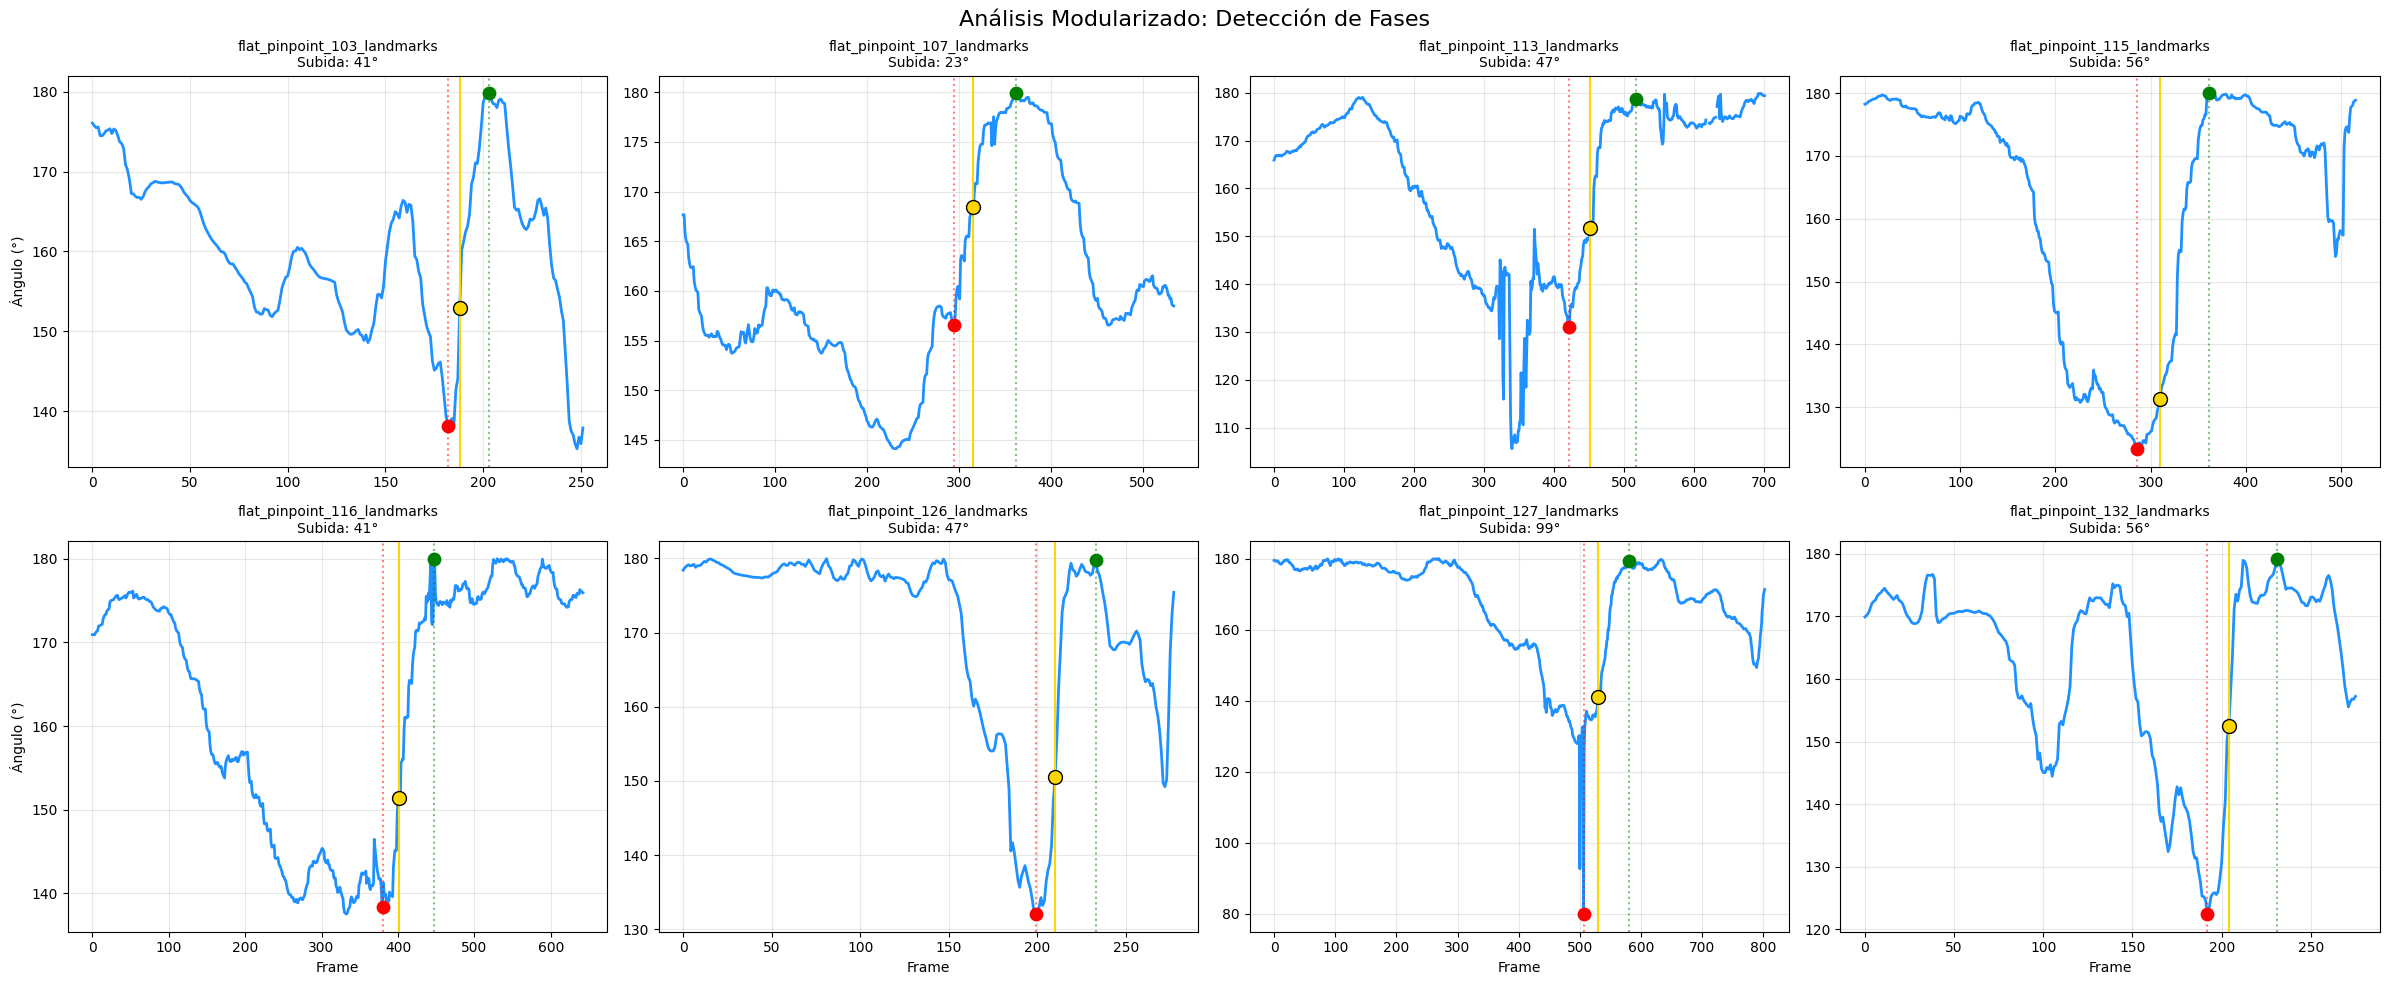

In [24]:
# --- BUCLE PRINCIPAL ---
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() 

for idx, file_path in enumerate(csv_files):
    try:
        df = pd.read_csv(file_path)
        
        # Calcular Ángulos
        angulos_izquierda = []
        for i in range(len(df)):
            l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            angulos_izquierda.append(calculate_angle(l_hip, l_knee, l_ankle))
        
        df['angulo'] = angulos_izquierda
        
        min_frame, max_frame, target_frame = detectar_fases_saque(df['angulo'], 100)
        
        # Extraer valores para pintar
        min_val = df.loc[min_frame, 'angulo']
        max_val = df.loc[max_frame, 'angulo']
        target_val = df.loc[target_frame, 'angulo']
        
        # PINTAR
        ax = axes[idx] 
        ax.plot(df['frame_id'], df['angulo'], color='dodgerblue', linewidth=2)
        
        # Puntos
        ax.scatter(df.loc[min_frame, 'frame_id'], min_val, color='red', s=80, zorder=5)
        ax.scatter(df.loc[max_frame, 'frame_id'], max_val, color='green', s=80, zorder=5)
        ax.scatter(df.loc[target_frame, 'frame_id'], target_val, color='gold', s=100, edgecolor='black', zorder=10)
        
        # Líneas
        ax.axvline(x=df.loc[min_frame, 'frame_id'], color='red', linestyle=':', alpha=0.5)
        ax.axvline(x=df.loc[max_frame, 'frame_id'], color='green', linestyle=':', alpha=0.5)
        ax.axvline(x=df.loc[target_frame, 'frame_id'], color='gold', linestyle='-', linewidth=1.5)
        
        # Decoración
        subida = int(max_val - min_val)
        ax.set_title(f"{file_path.stem}\nSubida: {subida}°", fontsize=10)
        ax.grid(True, alpha=0.3)
        
        if idx % 4 == 0: ax.set_ylabel("Ángulo (°)")
        if idx >= 4: ax.set_xlabel("Frame")

    except Exception as e:
        print(f"⚠️ Error en {file_path.name}: {e}")

plt.suptitle("Análisis Modularizado: Detección de Fases", fontsize=16)
plt.tight_layout()
plt.show()

Problema: Elegir un frame fijo da errores, ya que aunque x lógica 100 frames sería ideal, al haber videos a camara lenta lo mejor sería duplicar esos frames a 200 frames.

PASO 2: Aumentamos los frames y procedemos a obtener un target con el valor 0,325; ya que la media no es un valor fiable. Tan solo necesitamos que este un poco mas desplazado del punto minimo (maxima flexion de rodilla).

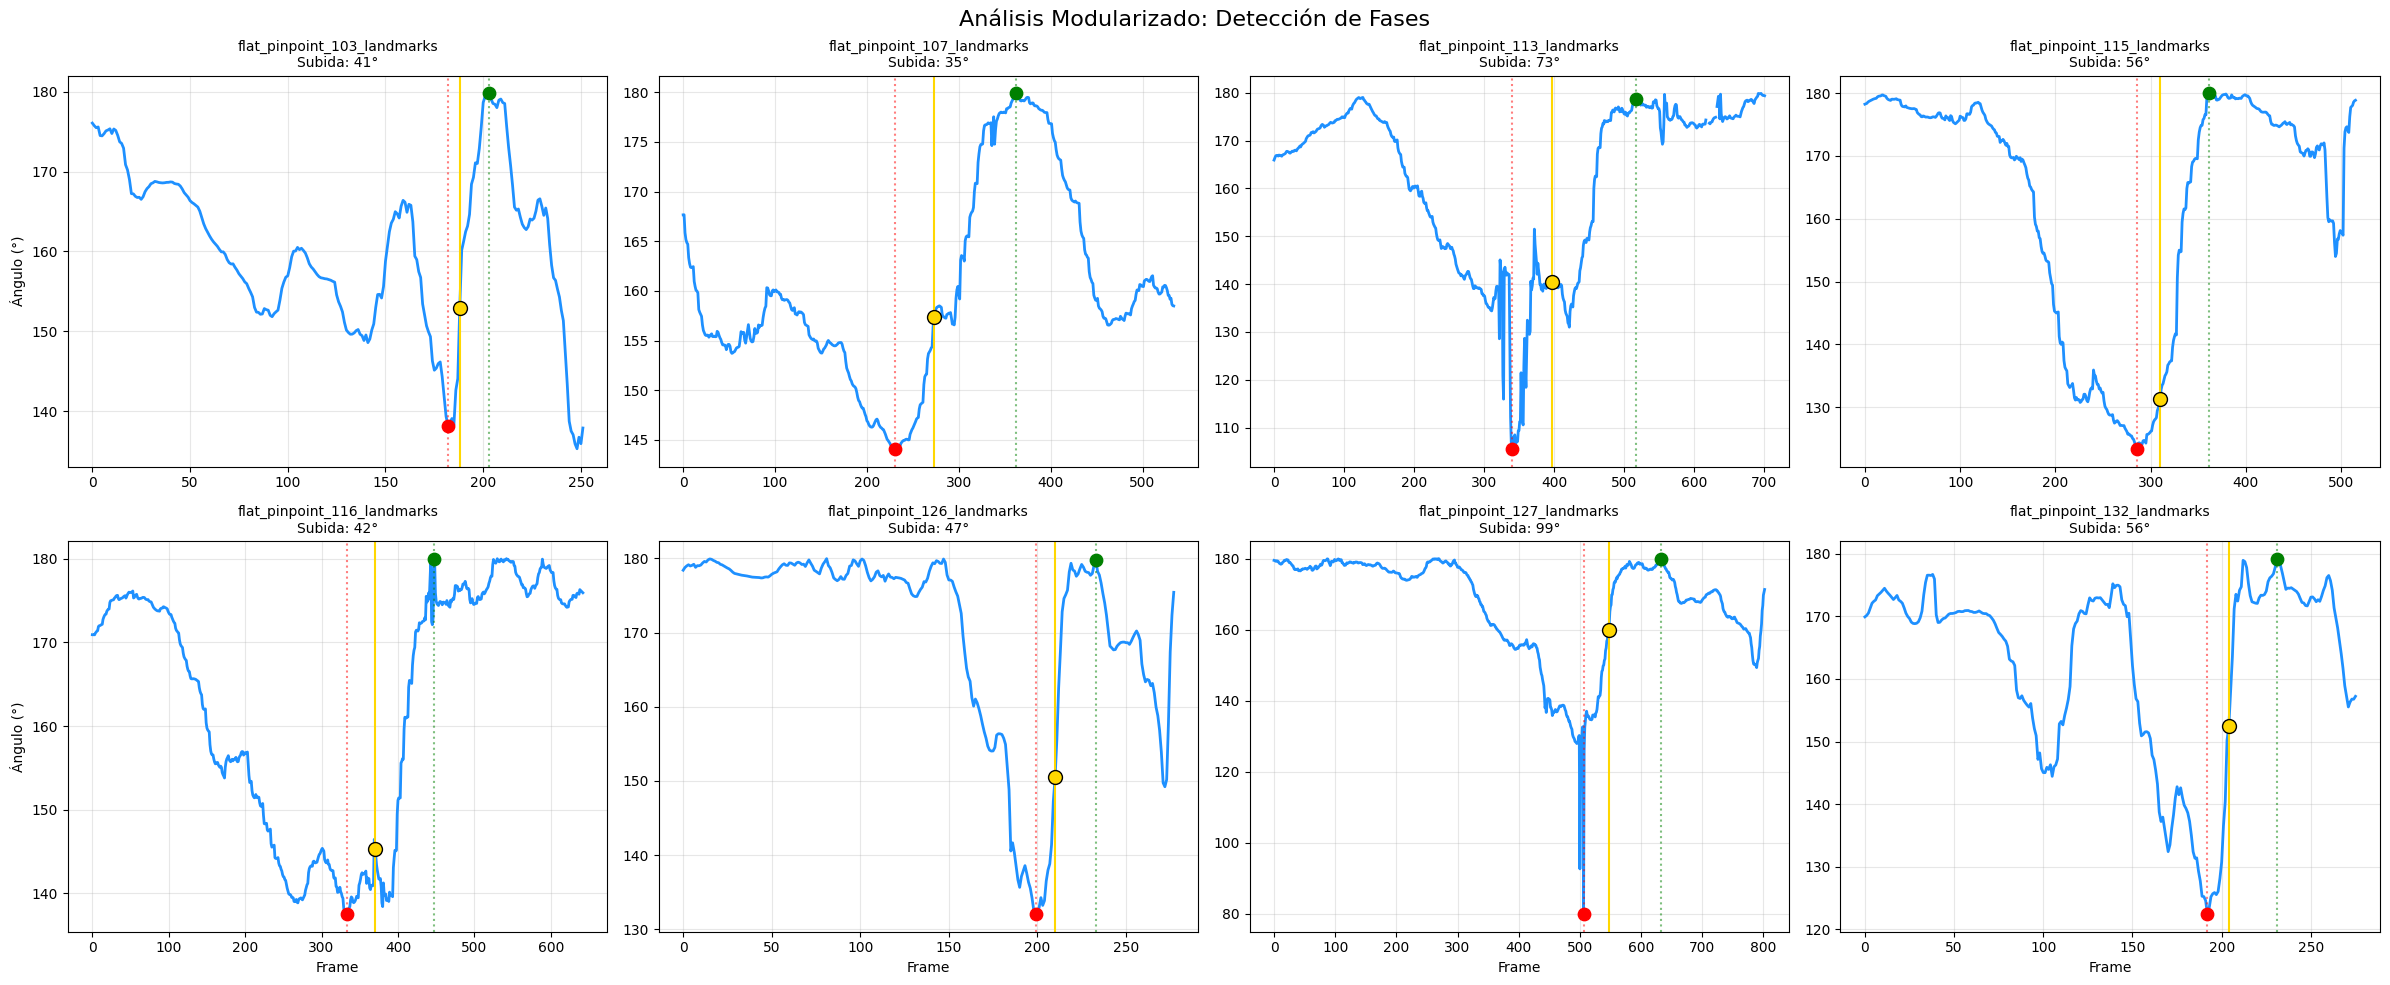

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() 

for idx, file_path in enumerate(csv_files):
    try:
        df = pd.read_csv(file_path)
        
        # Calcular Ángulos
        angulos_izquierda = []
        for i in range(len(df)):
            l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            angulos_izquierda.append(calculate_angle(l_hip, l_knee, l_ankle))
        
        df['angulo'] = angulos_izquierda
        
        min_frame, max_frame, target_frame = detectar_fases_saque(df['angulo'], 200)
        
        # Extraer valores para pintar
        min_val = df.loc[min_frame, 'angulo']
        max_val = df.loc[max_frame, 'angulo']
        target_val = df.loc[target_frame, 'angulo']
        
        # PINTAR
        ax = axes[idx] 
        ax.plot(df['frame_id'], df['angulo'], color='dodgerblue', linewidth=2)
        
        # Puntos
        ax.scatter(df.loc[min_frame, 'frame_id'], min_val, color='red', s=80, zorder=5)
        ax.scatter(df.loc[max_frame, 'frame_id'], max_val, color='green', s=80, zorder=5)
        ax.scatter(df.loc[target_frame, 'frame_id'], target_val, color='gold', s=100, edgecolor='black', zorder=10)
        
        # Líneas
        ax.axvline(x=df.loc[min_frame, 'frame_id'], color='red', linestyle=':', alpha=0.5)
        ax.axvline(x=df.loc[max_frame, 'frame_id'], color='green', linestyle=':', alpha=0.5)
        ax.axvline(x=df.loc[target_frame, 'frame_id'], color='gold', linestyle='-', linewidth=1.5)
        
        # Decoración
        subida = int(max_val - min_val)
        ax.set_title(f"{file_path.stem}\nSubida: {subida}°", fontsize=10)
        ax.grid(True, alpha=0.3)
        
        if idx % 4 == 0: ax.set_ylabel("Ángulo (°)")
        if idx >= 4: ax.set_xlabel("Frame")

    except Exception as e:
        print(f"⚠️ Error en {file_path.name}: {e}")

plt.suptitle("Análisis Modularizado: Detección de Fases", fontsize=16)
plt.tight_layout()
plt.show()

Ahora si tendriamos el target localizado.